In [14]:
# Importing the libraries
import pandas as pd
import numpy as np
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Reading the raw data and storing it into a dataframe
df = pd.read_csv('data.csv')
df.head()

,id,doi,title,display_name,relevance_score,publication_year,publication_date,language,type,type_crossref,...,locations.source.type,locations.source,sustainable_development_goals.id,sustainable_development_goals.score,sustainable_development_goals.display_name,grants.funder,grants.funder_display_name,grants.award_id,counts_by_year.year,counts_by_year.cited_by_count
0,https://openalex.org/W2044086157,https://doi.org/10.1007/s11747-015-0429-6,Does relationship marketing matter in online r...,Does relationship marketing matter in online r...,329.51544,2015,2015-02-17,en,article,journal-article,...,journal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025|2024|2023|2022|2021|2020|2019|2018|2017|2...,9|14|20|35|34|46|27|21|20|8|3
1,https://openalex.org/W4298132459,https://doi.org/10.1007/s10479-022-04983-y,Artificial intelligence and big data analytics...,Artificial intelligence and big data analytics...,259.89288,2022,2022-09-30,en,article,journal-article,...,journal|repository|repository,nan|nan|nan,NaN,NaN,NaN,NaN,NaN,NaN,2025|2024|2023|2022,69|86|34|3
2,https://openalex.org/W2884330163,https://doi.org/10.1111/joms.12393,Does the Diversification–Firm Performance Rela...,Does the Diversification–Firm Performance Rela...,234.70276,2018,2018-07-16,en,review,journal-article,...,journal|repository|repository|repository,nan|nan|nan|nan,NaN,NaN,NaN,NaN,NaN,NaN,2025|2024|2023|2022|2021|2020|2019|2018,15|25|26|19|24|13|11|2
3,https://openalex.org/W2037277508,https://doi.org/10.1080/00207549308956815,Estimation of number of AGVs for an FMS: an an...,Estimation of number of AGVs for an FMS: an an...,187.17949,1993,1993-07-01,en,article,journal-article,...,journal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023|2022|2021|2020|2019|2017|2016|2015|2014,1|3|2|1|2|1|4|1|1
4,https://openalex.org/W4387009663,https://doi.org/10.1002/mar.21908,Marketing analytics: The bridge between custom...,Marketing analytics: The bridge between custom...,172.37427,2023,2023-09-25,en,article,journal-article,...,journal,NaN,https://metadata.un.org/sdg/16,0.44,"Peace, justice, and strong institutions",NaN,NaN,NaN,2025|2024|2023,13|32|4


In [5]:
# Selecting the relevant columns for the analysis
selected_df = df[['title','authorships.raw_author_name']]
selected_df.head()

,title,authorships.raw_author_name
0,Does relationship marketing matter in online r...,Varsha Verma|Dheeraj Sharma|Jagdish Sheth
1,Artificial intelligence and big data analytics...,Efpraxia D. Zamani|Conn Smyth|Samrat Gupta|Den...
2,Does the Diversification–Firm Performance Rela...,Monika Schommer|Ansgar Richter|Amit Karna
3,Estimation of number of AGVs for an FMS: an an...,B. MAHADEVAN|T. T. NARENDRAN
4,Marketing analytics: The bridge between custom...,Rituparna Basu|Weng Marc Lim|Anil Kumar|Satish...


In [6]:
# Renaming the columns
selected_df = selected_df.rename(columns = {'authorships.raw_author_name':'authors'})
selected_df.head()

,title,authors
0,Does relationship marketing matter in online r...,Varsha Verma|Dheeraj Sharma|Jagdish Sheth
1,Artificial intelligence and big data analytics...,Efpraxia D. Zamani|Conn Smyth|Samrat Gupta|Den...
2,Does the Diversification–Firm Performance Rela...,Monika Schommer|Ansgar Richter|Amit Karna
3,Estimation of number of AGVs for an FMS: an an...,B. MAHADEVAN|T. T. NARENDRAN
4,Marketing analytics: The bridge between custom...,Rituparna Basu|Weng Marc Lim|Anil Kumar|Satish...


In [7]:
# Cleaning the 'authors' column by splitting it into a list of names
selected_df['author_list'] = selected_df['authors'].astype(str).str.split('|')

In [8]:
# Initiating an empty list to store all co-author pairs
co_author_pairs = []

In [9]:
# Creating the co-author pairs
for _,row in selected_df.iterrows():
    authors = row['author_list']
    authors = [author.strip() for author in authors if isinstance(author,str) and author.strip()]

    # Creating unique co-author pairs for every case where there are two or more authors
    if len(authors) > 1:
        pairs = list(combinations(authors,2))
        co_author_pairs.extend(pairs)
        

In [10]:
print(co_author_pairs)

[('Varsha Verma', 'Dheeraj Sharma'), ('Varsha Verma', 'Jagdish Sheth'), ('Dheeraj Sharma', 'Jagdish Sheth'), ('Efpraxia D. Zamani', 'Conn Smyth'), ('Efpraxia D. Zamani', 'Samrat Gupta'), ('Efpraxia D. Zamani', 'Denis Dennehy'), ('Conn Smyth', 'Samrat Gupta'), ('Conn Smyth', 'Denis Dennehy'), ('Samrat Gupta', 'Denis Dennehy'), ('Monika Schommer', 'Ansgar Richter'), ('Monika Schommer', 'Amit Karna'), ('Ansgar Richter', 'Amit Karna'), ('B. MAHADEVAN', 'T. T. NARENDRAN'), ('Rituparna Basu', 'Weng Marc Lim'), ('Rituparna Basu', 'Anil Kumar'), ('Rituparna Basu', 'Satish Kumar'), ('Weng Marc Lim', 'Anil Kumar'), ('Weng Marc Lim', 'Satish Kumar'), ('Anil Kumar', 'Satish Kumar'), ('Shanthan Kandula', 'Srikumar Krishnamoorthy'), ('Shanthan Kandula', 'Debjit Roy'), ('Srikumar Krishnamoorthy', 'Debjit Roy'), ('Debjit Roy', 'Eirini Spiliotopoulou'), ('Debjit Roy', 'Jelle de Vries'), ('Eirini Spiliotopoulou', 'Jelle de Vries'), ('Rohit Raj', 'Vimal Kumar'), ('Rohit Raj', 'Bhavin Shah'), ('Vimal Kuma

In [15]:
# Creating a graph object
G = nx.Graph()

# Adding edges to the graph from the co-author pairs
G.add_edges_from(co_author_pairs)

In [41]:
# Network Properties
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f'Number of nodes : {num_nodes}')
print(f'Number of edges: {num_edges}')

Number of nodes : 263
Number of edges: 442


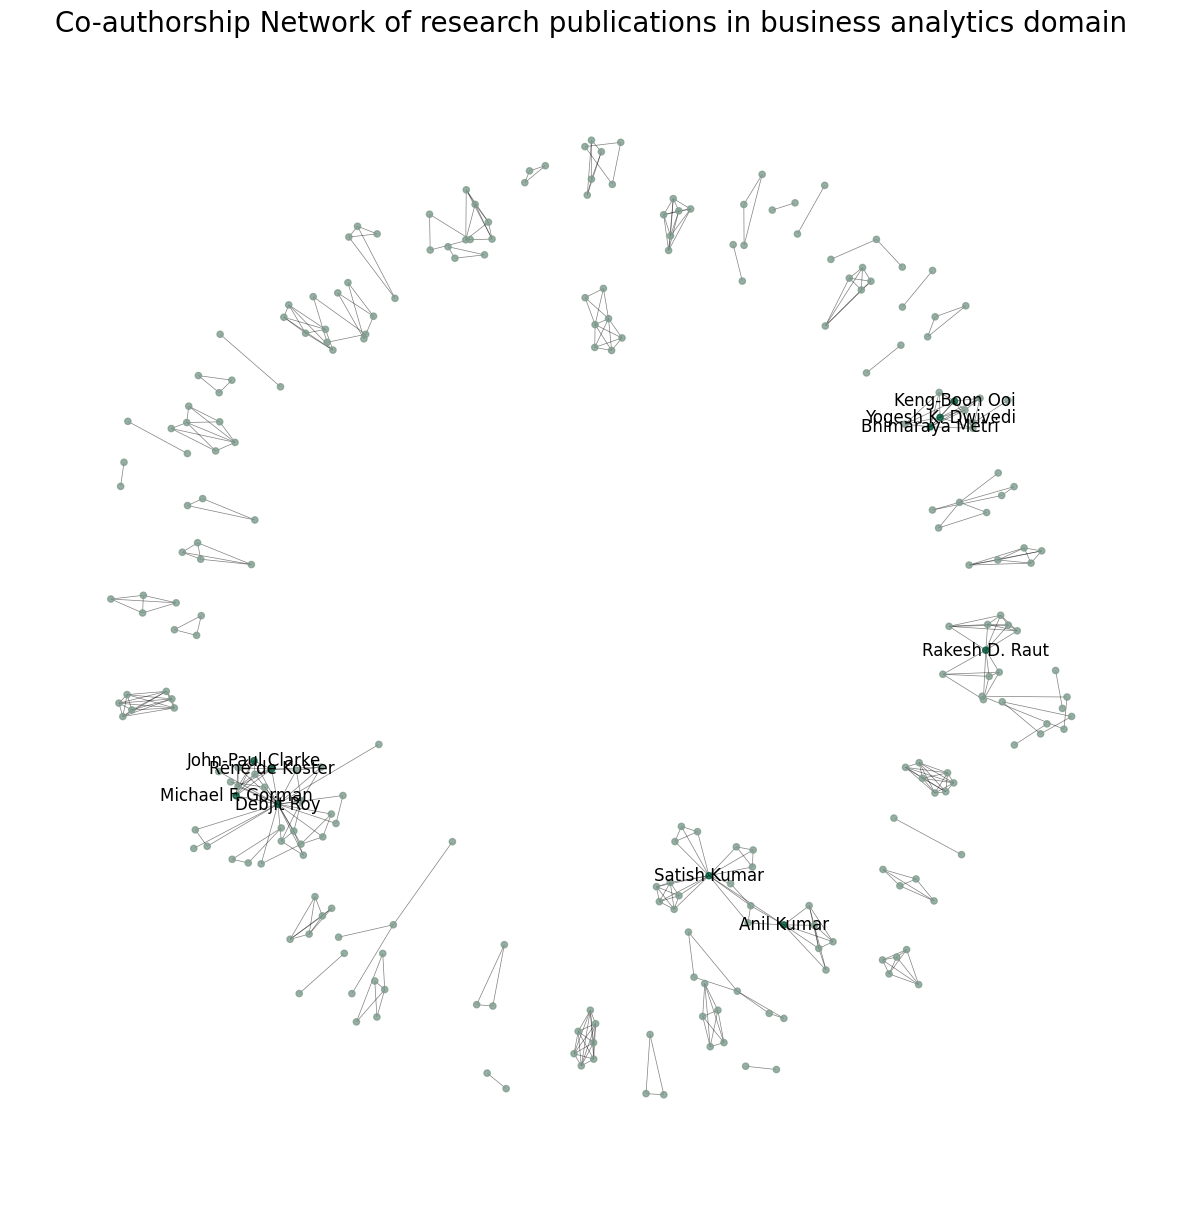

In [17]:
# Calculate the degree centrality
degree_centrality = nx.degree_centrality(G)
sorted_centrality = sorted(degree_centrality.items(), key = lambda item: item[1],reverse = True)
top_10_authors = [item[0] for item in sorted_centrality[:10]]

# Colour coding the nodes
node_colours = ['#00563B' if node in top_10_authors else '#7F9C8D' for node in G.nodes()]

# Position the nodes using a spring layout
pos = nx.spring_layout(G, k = 0.15, iterations = 50)

# Plotting the network
plt.figure(figsize = (15,15))

nx.draw_networkx_nodes(G, pos, node_size = 20, node_color = node_colours, alpha = 0.8)
nx.draw_networkx_edges(G, pos, width = 0.5, alpha = 0.5)

# Labelling the top 10 authors
labels = {node: node if node in top_10_authors else '' for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels = labels, font_size = 12, font_family='sans-serif')

# Plot title
plt.title("Co-authorship Network of research publications in business analytics domain", fontsize = 20)
plt.axis('off')

# Save the plot
plt.savefig('Co-authorhsip Network.png')

C:\Users\GJ317EV\AppData\Local\Temp\ipykernel_7104\494948926.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'Degree Centrality', y = 'Author',data = top_10_authors, palette = colors)


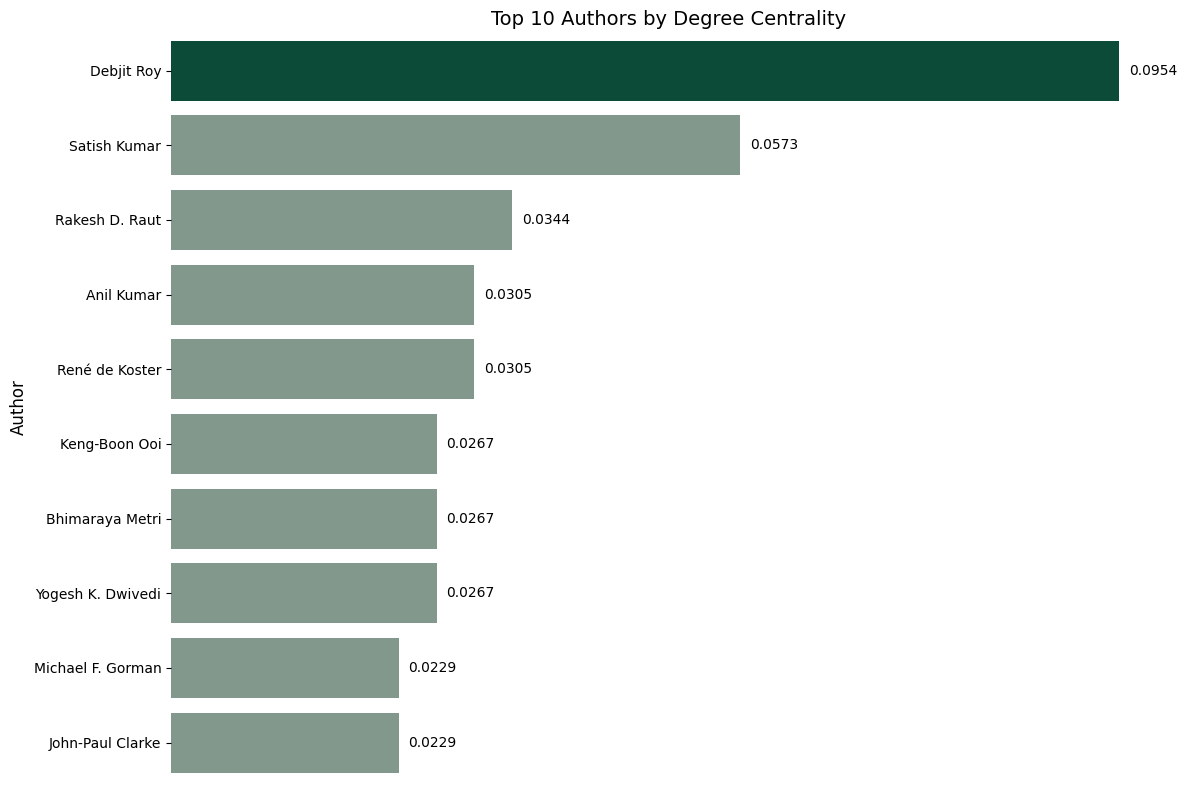

In [23]:
#  Degree of the network
degree_centrality = nx.degree_centrality(G)
sorted_degree_centrality = sorted(degree_centrality.items(), key = lambda item: item[1], reverse = True)
degree_df = pd.DataFrame(sorted_degree_centrality, columns = ['Author','Degree Centrality'])
top_10_authors = degree_df.head(10)

# Creating a colour palette for basis degree centrality
max_degree = top_10_authors['Degree Centrality'].max()
colors = ['#00563B' if val == max_degree else '#7F9C8D' for val in top_10_authors['Degree Centrality']]

# Creating a bar chart using the color palette
plt.figure(figsize = (12,8))
ax = sns.barplot(x = 'Degree Centrality', y = 'Author',data = top_10_authors, palette = colors)

# Plot hygiene
plt.xlabel('Degree Centrality', fontsize = 12)
plt.ylabel('Author', fontsize = 12)
for index, row in top_10_authors.iterrows():
    ax.text(row['Degree Centrality'] + 0.001, index, f"{row['Degree Centrality']:.4f}",
            color='black', ha="left", va="center")

ax.set_xlabel('')
ax.set_xticks([])

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.title("Top 10 Authors by Degree Centrality", fontsize = 14)

# Save the plot
plt.tight_layout()
plt.savefig('degree.png')

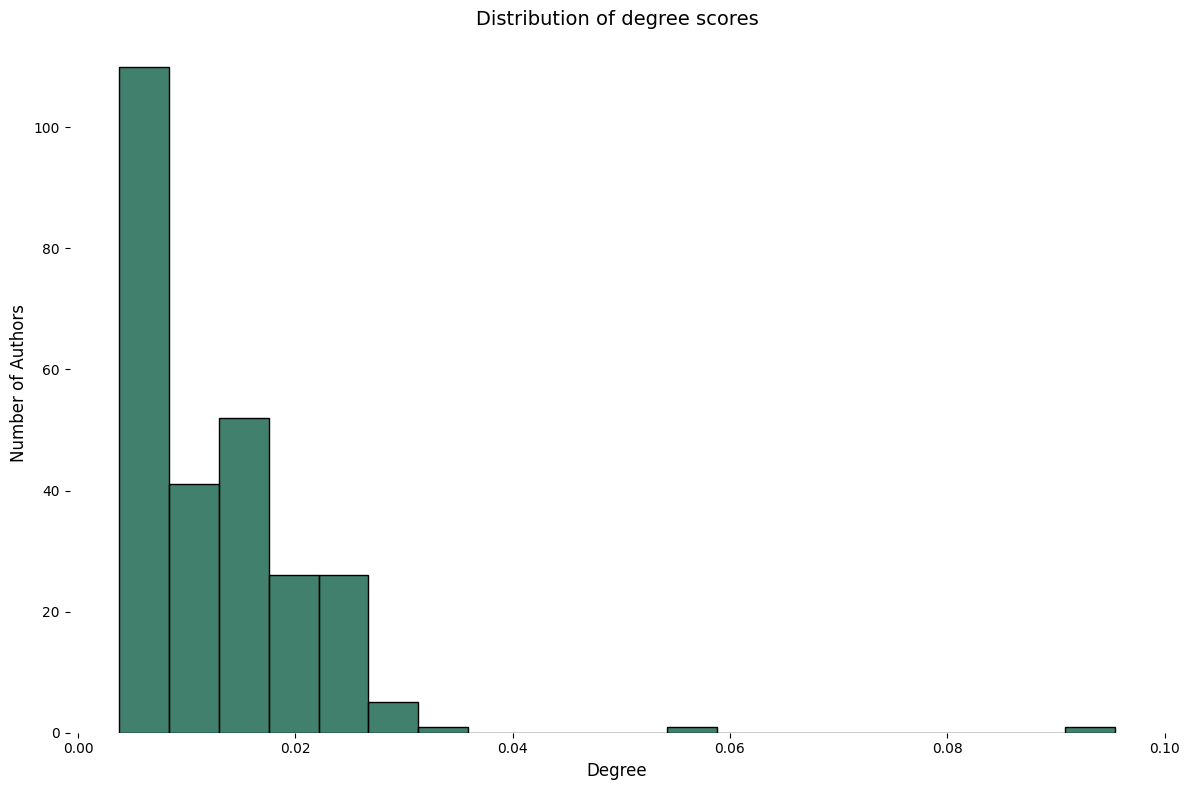

In [22]:
# Histogram for degree scores
plt.figure(figsize = (12,8))

sns.histplot(degree_df['Degree Centrality'], kde = False, bins = 20, color = '#00563B')

plt.title('Distribution of degree scores', fontsize = 14)

plt.xlabel('Degree',fontsize = 12)

plt.ylabel('Number of Authors',fontsize = 12)

for spine in plt.gca().spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.savefig('degree_histogram.png')

C:\Users\GJ317EV\AppData\Local\Temp\ipykernel_7104\592001990.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'Betweenness Centrality', y = 'Author',data = top_10_authors, palette = colors)


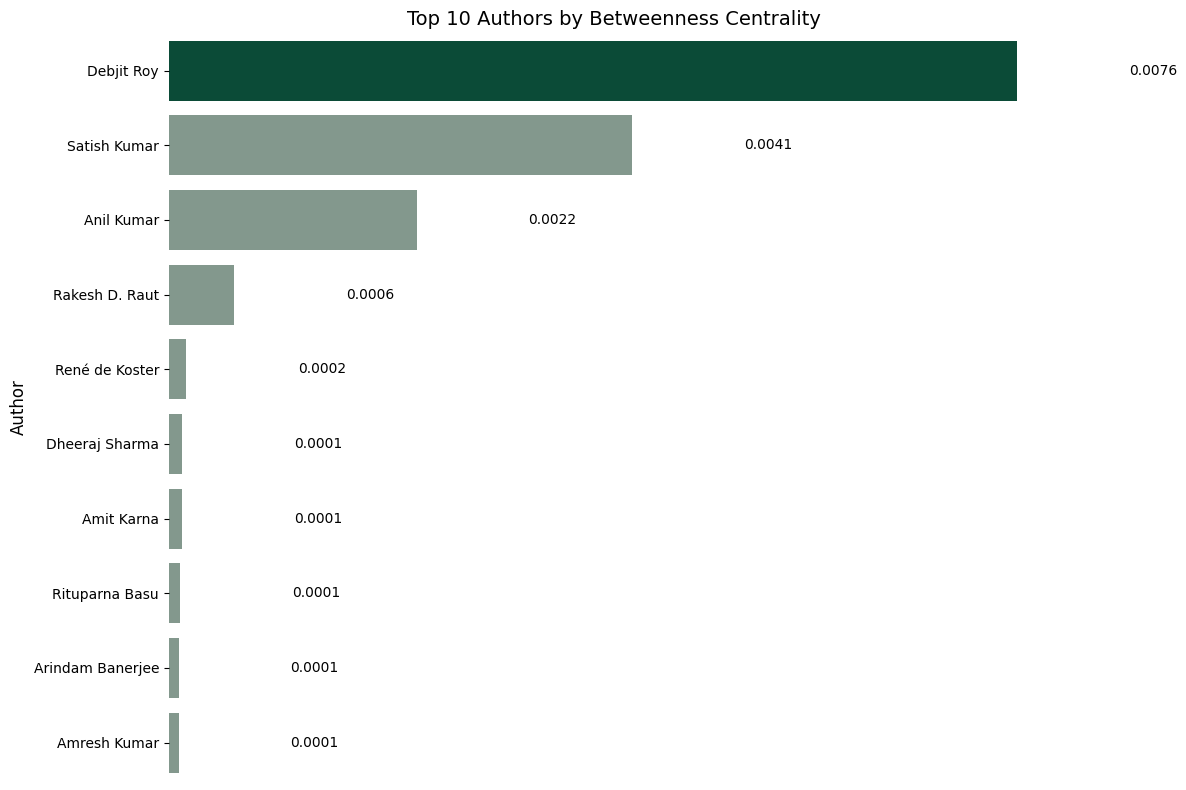

In [28]:
# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)
sorted_betweenness_centrality = sorted(betweenness_centrality.items(), key = lambda item: item[1],reverse = True)
betweenness_df = pd.DataFrame(sorted_betweenness_centrality, columns = ['Author','Betweenness Centrality'])
top_10_authors = betweenness_df.head(10)

# Creating a colour palette for basis degree centrality
max_betweenness = top_10_authors['Betweenness Centrality'].max()
colors = ['#00563B' if val == max_betweenness else '#7F9C8D' for val in top_10_authors['Betweenness Centrality']]

# Creating a bar chart using the color palette
plt.figure(figsize = (12,8))
ax = sns.barplot(x = 'Betweenness Centrality', y = 'Author',data = top_10_authors, palette = colors)

# Plot hygiene
plt.xlabel('Betweenness Centrality', fontsize = 12)
plt.ylabel('Author', fontsize = 12)
for index, row in top_10_authors.iterrows():
    ax.text(row['Betweenness Centrality'] + 0.001, index, f"{row['Betweenness Centrality']:.4f}",
            color='black', ha="left", va="center")

ax.set_xlabel('')
ax.set_xticks([])

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.title("Top 10 Authors by Betweenness Centrality", fontsize = 14)

# Save the plot
plt.tight_layout()
plt.savefig('betweenness.png')

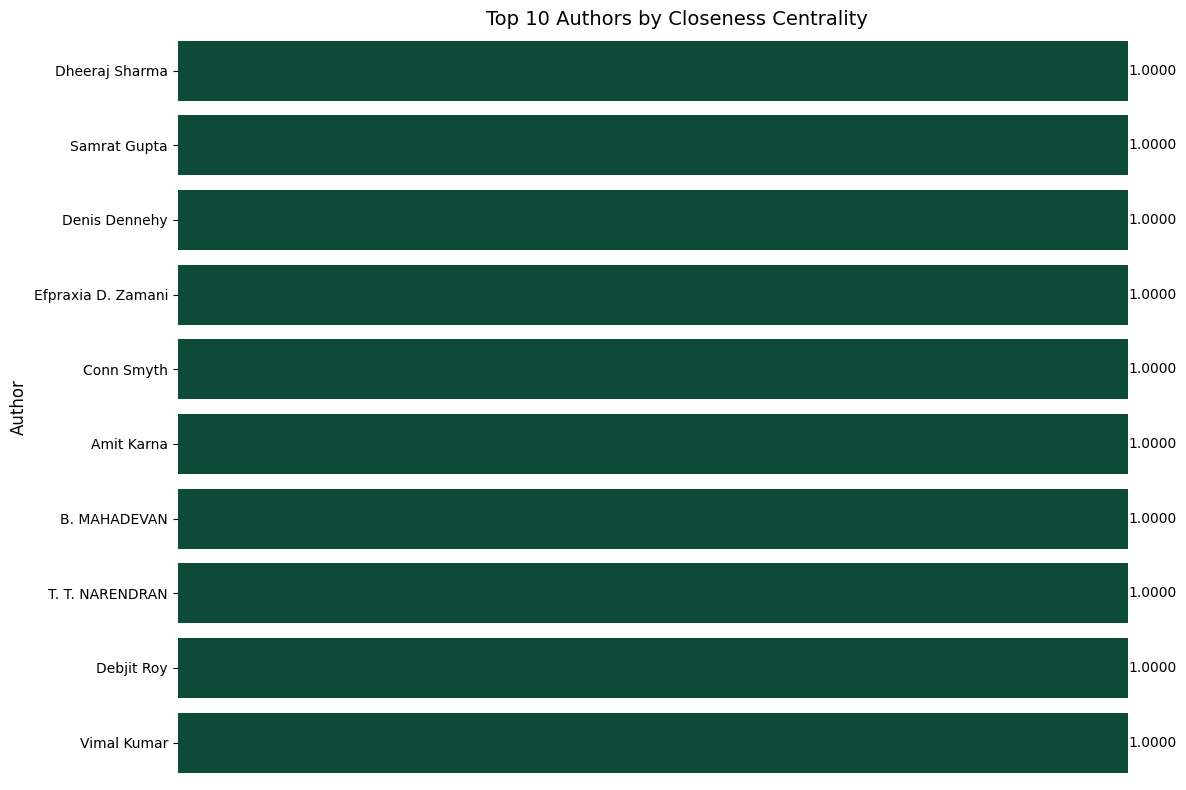

In [31]:
# Closeness Centrality
closeness_centrality = {}

for component in nx.connected_components(G):
    subgraph = G.subgraph(component)
    cc = nx.closeness_centrality(subgraph)
    closeness_centrality.update(cc)

sorted_closeness_centrality = sorted(closeness_centrality.items(), key = lambda item: item[1], reverse = True)
closeness_df = pd.DataFrame(sorted_closeness_centrality,columns= ['Author','Closeness Centrality'])
top_10_authors = closeness_df.head(10)

# Creating the bar chart
plt.figure(figsize = (12,8))
ax = sns.barplot(x = 'Closeness Centrality', y = 'Author',data = top_10_authors, color = '#00563B')

# Plot hygiene
plt.xlabel('Closeness Centrality', fontsize = 12)
plt.ylabel('Author', fontsize = 12)
for index, row in top_10_authors.iterrows():
    ax.text(row['Closeness Centrality'] + 0.001, index, f"{row['Closeness Centrality']:.4f}",
            color='black', ha="left", va="center")

ax.set_xlabel('')
ax.set_xticks([])

sns.despine(left=True, bottom=True)

plt.title("Top 10 Authors by Closeness Centrality", fontsize = 14)

# Save the plot
plt.tight_layout()
plt.savefig('closeness.png')


In [33]:
# Analysing the components
components = list(nx.connected_components(G))

sorted_components = sorted(components,key = len, reverse = True)

# Print the number of components
print(f"Total number of connected components: {len(components)}")

# Print the size of the top 10 components
print("\nSize of the top 10 components: ")
for i, component in enumerate(sorted_components[:10]):
    print(f"Component {i+1} : {len(component)} authors")

Total number of connected components: 59

Size of the top 10 components: 
Component 1 : 26 authors
Component 2 : 21 authors
Component 3 : 10 authors
Component 4 : 8 authors
Component 5 : 7 authors
Component 6 : 7 authors
Component 7 : 7 authors
Component 8 : 7 authors
Component 9 : 6 authors
Component 10 : 6 authors


C:\Users\GJ317EV\AppData\Local\Temp\ipykernel_7104\2072387102.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = 'Eigenvector Centrality', y = 'Author',data = top_10_authors, palette = colors)


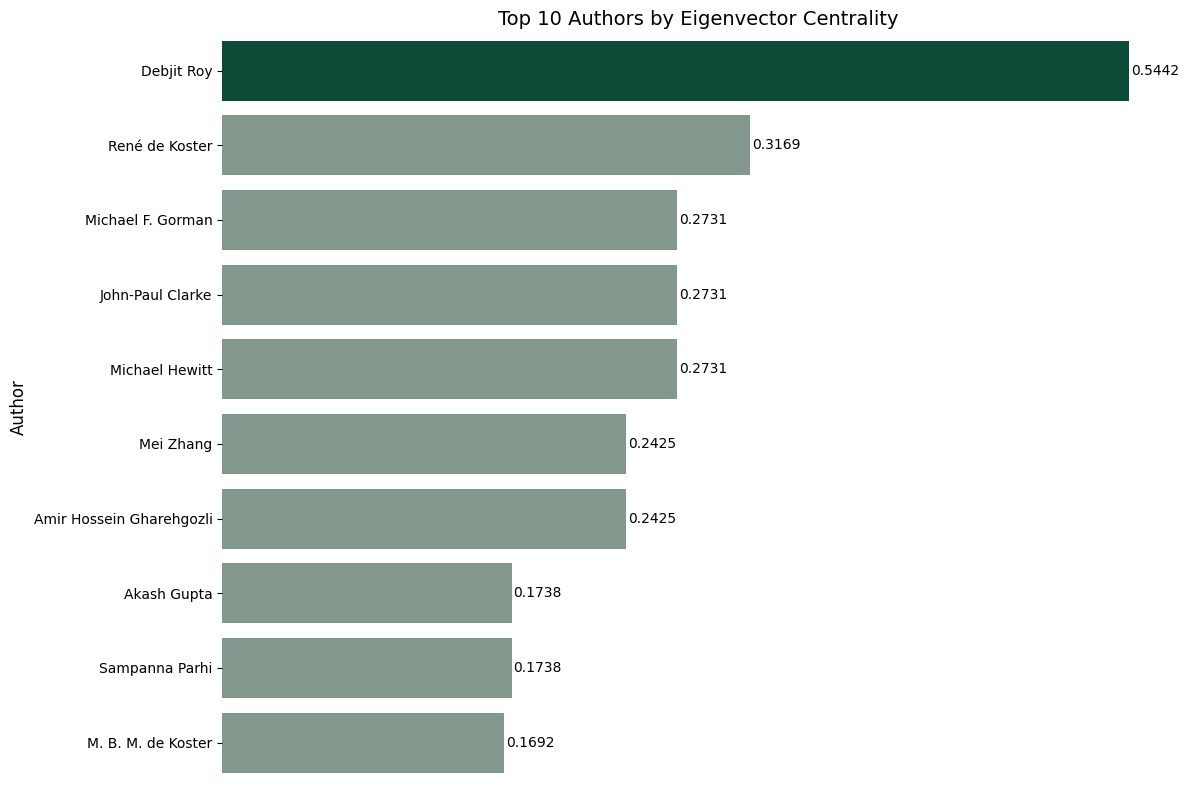

In [40]:
# Eigen vector centrality
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter = 1000)

    sorted_centrality = sorted(eigenvector_centrality.items(), key =lambda item:item[1],reverse = True)
    
    eigenvector_df = pd.DataFrame(sorted_centrality, columns = ['Author','Eigenvector Centrality'])
    top_10_authors = eigenvector_df.head(10)

    max_centrality = top_10_authors['Eigenvector Centrality'].max()
    colors = ['#00563B' if val == max_centrality else '#7F9C8D' for val in top_10_authors['Eigenvector Centrality']]

    plt.figure(figsize = (12,8))
    ax = sns.barplot(x = 'Eigenvector Centrality', y = 'Author',data = top_10_authors, palette = colors)

    plt.xlabel('Eigenvector Centrality', fontsize = 12)
    plt.ylabel('Author', fontsize = 12)
    for index, row in top_10_authors.iterrows():
        ax.text(row['Eigenvector Centrality'] + 0.001, index, f"{row['Eigenvector Centrality']:.4f}",
                color='black', ha="left", va="center")

    ax.set_xlabel('')
    ax.set_xticks([])

    sns.despine(left=True, bottom=True)

    plt.title("Top 10 Authors by Eigenvector Centrality", fontsize = 14)

    # Save the plot
    plt.tight_layout()
    plt.savefig('eigenvector.png')

except nx.PowerIterationFailedConvergence as e:
    print(f"An error occurred: {e}. Eigenvector centrality could not be computed.")
    print("This can happen in a disconnected network or with certain graph structures.")


In [42]:
# Empirical network
G_empirical = nx.Graph()
G_empirical.add_edges_from(co_author_pairs)

n = G_empirical.number_of_nodes()
m = G_empirical.number_of_edges()

empirical_degrees = sorted([d for n, d in G_empirical.degree()], reverse=True)

In [43]:
# Random Graph model (100 Simulations)
p = m / (n * (n - 1) / 2)
random_degrees_list = []
for _ in range(100):
    G_random = nx.erdos_renyi_graph(n, p)
    random_degrees = sorted([d for n, d in G_random.degree()], reverse=True)
    random_degrees_list.append(random_degrees)
avg_random_degrees = np.mean(random_degrees_list, axis=0)

In [44]:
# Barabasi-Albert model
m_ba = 2  # A common value for Barabasi-Albert model
G_ba = nx.barabasi_albert_graph(n, m_ba)
ba_degrees = sorted([d for n, d in G_ba.degree()], reverse=True)

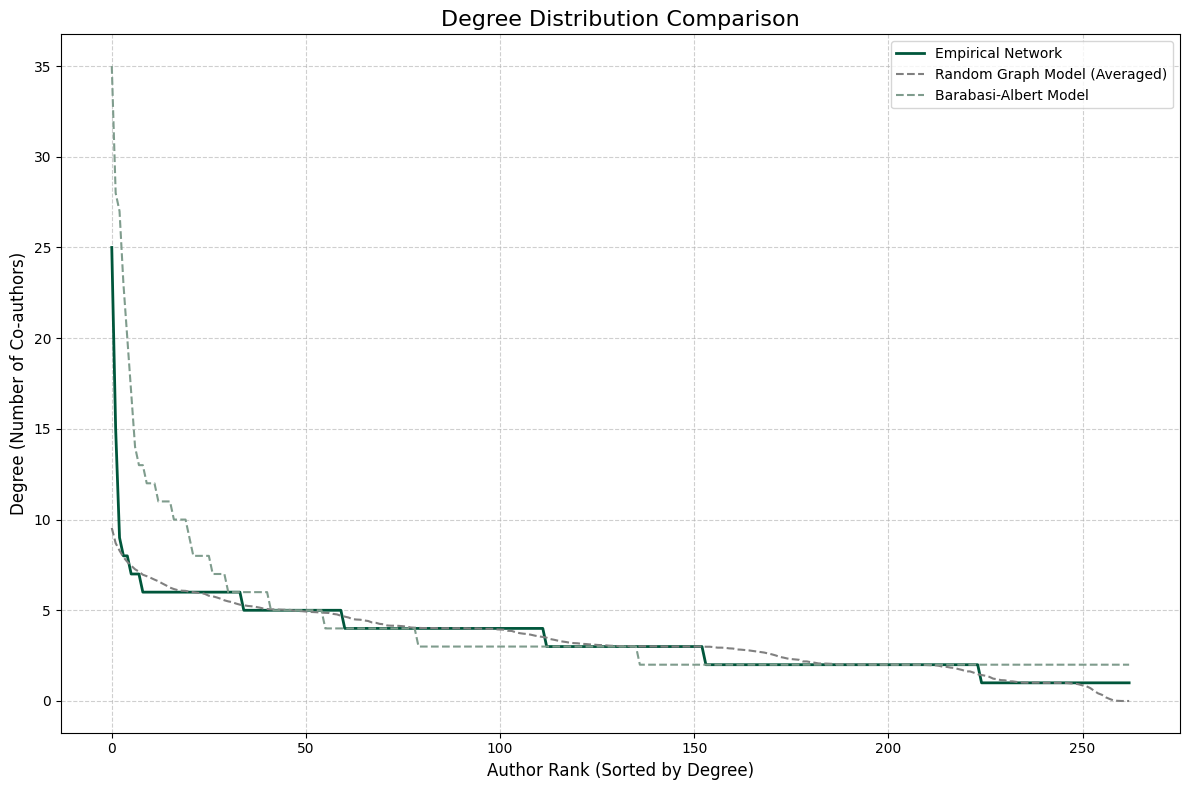

In [45]:
# Compare and Visualize the Degree Distributions
plt.figure(figsize=(12, 8))
plt.plot(empirical_degrees, label='Empirical Network', color='#00563B', linewidth=2)
plt.plot(avg_random_degrees, label='Random Graph Model (Averaged)', color='gray', linestyle='--')
plt.plot(ba_degrees, label='Barabasi-Albert Model', color='#7F9C8D', linestyle='--')

plt.title('Degree Distribution Comparison', fontsize=16)

plt.xlabel('Author Rank (Sorted by Degree)', fontsize=12)
plt.ylabel('Degree (Number of Co-authors)', fontsize=12)

plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('degree_distribution_comparison.png')